In [20]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from src.database import load_motorcycles_from_db

## Read the data 

In [21]:
df = load_motorcycles_from_db()

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              357 non-null    str    
 1   Country of Origin    357 non-null    str    
 2   Model                357 non-null    str    
 3   Number of cc         357 non-null    float64
 4   Horsepower           357 non-null    float64
 5   Torque               357 non-null    float64
 6   Transmission Type    357 non-null    str    
 7   Drivetrain           357 non-null    str    
 8   Number of Seating    357 non-null    int64  
 9   Year                 357 non-null    int64  
 10  Looks                357 non-null    str    
 11  Body Type            357 non-null    str    
 12  Engine Type          357 non-null    str    
 13  Number of Cylinders  357 non-null    float64
 14  Price (SEK)          357 non-null    float64
 15  Usage Type           357 non-null    str    
dtypes

### The dropna
the dropna is before we did work on the csv file so it's not necesery at the moment but im going to keep it in to show how our progres went

In [23]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              357 non-null    str    
 1   Country of Origin    357 non-null    str    
 2   Model                357 non-null    str    
 3   Number of cc         357 non-null    float64
 4   Horsepower           357 non-null    float64
 5   Torque               357 non-null    float64
 6   Transmission Type    357 non-null    str    
 7   Drivetrain           357 non-null    str    
 8   Number of Seating    357 non-null    int64  
 9   Year                 357 non-null    int64  
 10  Looks                357 non-null    str    
 11  Body Type            357 non-null    str    
 12  Engine Type          357 non-null    str    
 13  Number of Cylinders  357 non-null    float64
 14  Price (SEK)          357 non-null    float64
 15  Usage Type           357 non-null    str    
dtypes

## Spliting the data
after many trail and errors these are the values needed to for our model

In [24]:
categorical_features = [
    "Company",
    "Body Type",
    "Looks",
    "Country of Origin",
    "Transmission Type",
    "Drivetrain"
]

numeric_features = [
    "Number of cc",
    "Horsepower",
    "Torque",
    "Year",
    "Number of Cylinders",
    "Number of Seating",
]

x = df[categorical_features + numeric_features]
y = df["Price (SEK)"]

## Train, Val, Test
simple spliting the data into train val test for the complete workflow

In [25]:
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=42)

### preprocess 
this is to transform the categorial features so it can be used in the training. 
without it those features are worthless for the modeling

In [26]:
# Convert categorical features to numerical values and keep numerical features unchanged.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

## Linear regression
initialising train and prediction with the preprocessor

In [27]:
lin_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())])
lin_reg.fit(x_train, y_train)
lin_reg_pred = lin_reg.predict(x_val)

### Evalutation
evaluating the scores to see how well the linear regression model preforms

In [28]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

result = regression_metrics(y_val, lin_reg_pred)
print(result)

{'RMSE': 11953.578047911047, 'MSE': 142888028.14750087, 'MAE': 8355.51895868347}


## First evaluation for linear regression and it preformed not as well as i would hope.

===================================================================================================================================================================

## Trying forest with hyper params
trying differant hyper params to see wich preforms best

In [29]:
tree_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))])
hyperparameters = {
    "model__n_estimators": [210, 220, 230],
    "model__max_depth": [None, 5, 10, 12],
    "model__min_samples_split": [2, 3],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.5, 0.8]
}


tree_reg_gs = GridSearchCV(tree_reg, hyperparameters, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, return_train_score=True)
tree_reg_gs.fit(x_train, y_train)

tree_reg_pred = tree_reg_gs.predict(x_val)
print("Best hyperparameters:", tree_reg_gs.best_params_)
pd.DataFrame(tree_reg_gs.cv_results_)

Best hyperparameters: {'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 210}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__max_features,param_model__min_samples_leaf,param_model__min_samples_split,param_model__n_estimators,params,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.434273,0.042563,0.063305,0.016685,None,sqrt,1,2,210,"{'model__max_depth': None, 'model__max_feature...",...,-41181.002335,33965.540085,24,-21072.567285,-10520.557618,-23210.920973,-22487.142602,-23483.594979,-20154.956692,4889.202315
1,0.424979,0.045299,0.068442,0.005251,None,sqrt,1,2,220,"{'model__max_depth': None, 'model__max_feature...",...,-41225.947000,33937.519213,30,-21266.260555,-10508.517370,-23429.338506,-22769.855729,-23755.982344,-20345.990901,4992.654134
2,0.452986,0.048015,0.069451,0.010696,None,sqrt,1,2,230,"{'model__max_depth': None, 'model__max_feature...",...,-41304.933096,34075.024526,34,-21143.753420,-10485.229279,-23293.346799,-22588.378333,-23528.388544,-20207.819275,4931.905327
3,0.390919,0.011867,0.062697,0.004084,None,sqrt,1,3,210,"{'model__max_depth': None, 'model__max_feature...",...,-41673.014715,33771.866138,41,-25198.614100,-12974.773661,-26003.942293,-25109.127363,-27418.111091,-23340.913701,5248.804616
4,0.386057,0.016135,0.064047,0.005293,None,sqrt,1,3,220,"{'model__max_depth': None, 'model__max_feature...",...,-41729.720500,33856.142962,44,-25400.098852,-12927.189619,-26093.180743,-25326.653296,-27653.871882,-23480.198878,5342.445785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.470151,0.025957,0.080744,0.003459,12,0.8,2,2,220,"{'model__max_depth': 12, 'model__max_features'...",...,-44418.837071,33236.045554,113,-39623.923572,-13937.940632,-40111.193876,-37907.532246,-41615.732879,-34639.264641,10418.122020
140,0.491379,0.017889,0.077321,0.011085,12,0.8,2,2,230,"{'model__max_depth': 12, 'model__max_features'...",...,-44389.638754,33218.050815,111,-39554.346292,-13926.976163,-40101.240839,-37878.980937,-41488.081319,-34589.925110,10395.960612
141,0.479892,0.008227,0.072156,0.007280,12,0.8,2,3,210,"{'model__max_depth': 12, 'model__max_features'...",...,-44388.676684,33263.583260,109,-39645.259133,-13925.170366,-40059.735144,-37736.847411,-41473.367619,-34568.075935,10390.282251
142,0.457201,0.022266,0.061823,0.005524,12,0.8,2,3,220,"{'model__max_depth': 12, 'model__max_features'...",...,-44418.837071,33236.045554,114,-39623.923572,-13937.940632,-40111.193876,-37907.532246,-41615.732879,-34639.264641,10418.122020


### Evalutation
evalutaing the score for Random forest regression

In [30]:
tree_rmse = root_mean_squared_error(y_val,tree_reg_pred)
tree_mse = mean_squared_error(y_val, tree_reg_pred)
tree_mae = mean_absolute_error(y_val, tree_reg_pred)

print("RMSE tree_regresssion: ", tree_rmse)
print("MSE tree_regression: ", tree_mse)
print("MAE tree_regression: ", tree_mae)

RMSE tree_regresssion:  14918.400025180714
MSE tree_regression:  222558659.31131193
MAE tree_regression:  9543.563169164157


===================================================================================================================

## Which model is better?
the linear one preformed better than rfr model

In [31]:
rf_categorical_features = [feature for feature in categorical_features if feature != "Model"]


tree_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])
hyperparameters = {
    'model__max_depth': [12],
    'model__max_features': [0.5], 
    'model__min_samples_leaf': [1], 
    'model__min_samples_split': [3], 
    'model__n_estimators': [230]
}


tree_reg_gs = GridSearchCV(
    tree_reg,
    hyperparameters,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

tree_reg_gs.fit(x_train_val, y_train_val)
tree_reg_pred = tree_reg_gs.predict(x_test)

In [32]:
tree_rmse = root_mean_squared_error(y_test,tree_reg_pred)
tree_mse = mean_squared_error(y_test, tree_reg_pred)
tree_mae = mean_absolute_error(y_test, tree_reg_pred)

print("RMSE tree_regresssion: ", tree_rmse)
print("MSE tree_regression: ", tree_mse)
print("MAE tree_regression: ", tree_mae)

RMSE tree_regresssion:  59565.73070121737
MSE tree_regression:  3548076273.9699497
MAE tree_regression:  23792.453654979065


### Visualization
here we just plot out the prediction compared to the data.

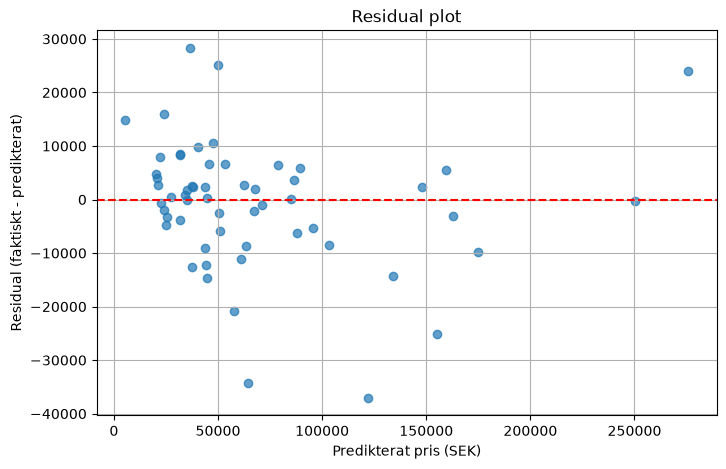

In [33]:
residuals = y_val - lin_reg_pred

plt.figure(figsize=(8, 5))

plt.scatter(lin_reg_pred, residuals, alpha=0.7)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predikterat pris (SEK)")
plt.ylabel("Residual (faktiskt - predikterat)")
plt.title("Residual plot")
plt.grid(True)

plt.show()


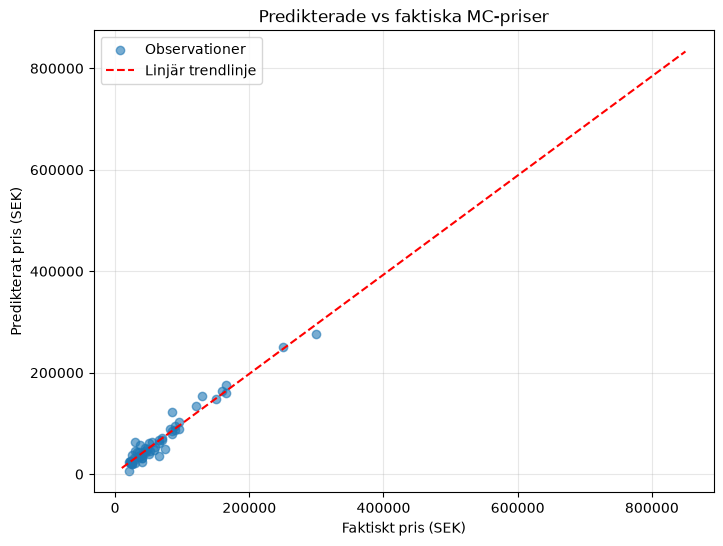

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, lin_reg_pred, alpha=0.6, label="Observationer")

line_slope, line_intercept = np.polyfit(y_val, lin_reg_pred, 1)
line_x = np.array([y_test.min(), y_test.max()])
line_y = line_slope * line_x + line_intercept

plt.plot(
    line_x,
    line_y,
    color="red",
    linestyle="--",
    label="Linjär trendlinje"
)

plt.xlabel("Faktiskt pris (SEK)")
plt.ylabel("Predikterat pris (SEK)")
plt.title("Predikterade vs faktiska MC-priser")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

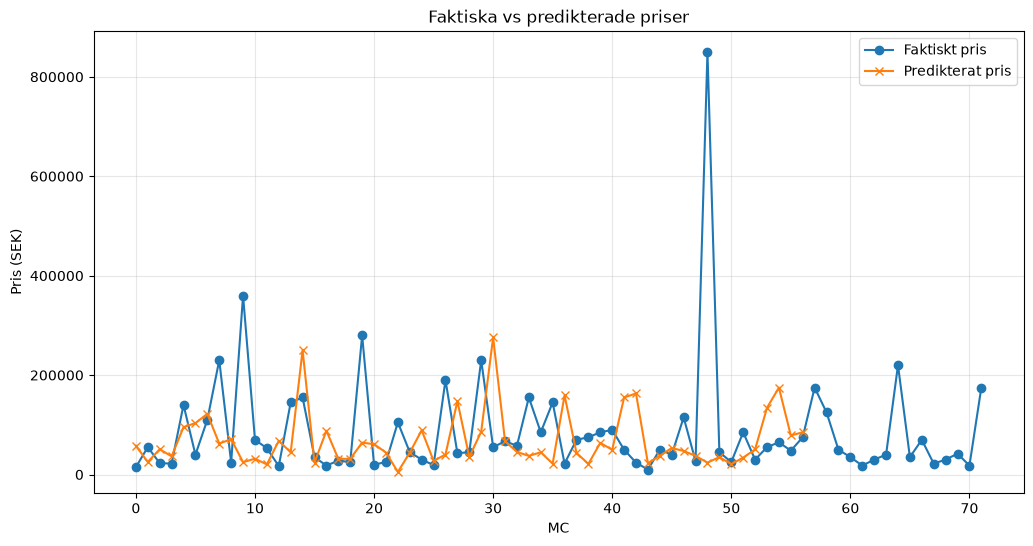

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label="Faktiskt pris", marker="o")
plt.plot(lin_reg_pred, label="Predikterat pris", marker="x")

plt.xlabel("MC")
plt.ylabel("Pris (SEK)")
plt.title("Faktiska vs predikterade priser")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## The best model in the end was Linear Regression so now we train it on the full dataset and save it.

In [36]:
lin_final_test = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
lin_final_test.fit(x_train_val, y_train_val)
lin_reg_last = lin_final_test.predict(x_test)

# Train the tuned random forest without the Model feature on the complete dataset.
rf_finished = tree_reg_gs.best_estimator_.fit(x_train_val, y_train_val)
rf_fin_pred = tree_reg_gs.predict(x_test)

print("RMSE LR: ", root_mean_squared_error(y_test, lin_reg_last))
print("RMSE RFR:", root_mean_squared_error(y_test, rf_fin_pred))

RMSE LR:  31973.978575766843
RMSE RFR: 59565.73070121737


In [37]:
lr_finished = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
lr_finished.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Company','Body Type','Looks',...,'Year','Number of Cylinders', 'Number of Seating']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

In [38]:
joblib.dump(lr_finished, "../streamlit/models/Linear_model.joblib")
print("Models saved")

Models saved
